# HELIX Revenue Prediction

## Notebook 06 — Correlation & Feature Dependency

Objective

Analyze feature relationships before feature engineering
and baseline model development.

In [2]:
# import library
from pathlib import Path

import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import LabelEncoder

from statsmodels.stats.outliers_influence import variance_inflation_factor

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [3]:
# load dataset
PROJECT_ROOT = Path("..")

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "ecommerce_customer_behavior_dataset_v2.csv"

df = pd.read_csv(DATA_PATH)

df["Date"] = pd.to_datetime(df["Date"])

In [4]:
# data preparation
TARGET = "Total_Amount"

drop_columns = ["Order_ID", "Customer_ID", "Unit_Price", "Quantity", "Discount_Amount"]

analysis_df = df.drop(columns=drop_columns).copy()

analysis_df["Year"] = analysis_df["Date"].dt.year
analysis_df["Month"] = analysis_df["Date"].dt.month
analysis_df["Day"] = analysis_df["Date"].dt.day
analysis_df["Weekday"] = analysis_df["Date"].dt.weekday

analysis_df = analysis_df.drop(columns="Date")

In [5]:
# numerical correlation
numeric_df = analysis_df.select_dtypes(include=np.number)

corr = numeric_df.corr()

corr

,Age,Total_Amount,Session_Duration_Minutes,Pages_Viewed,Delivery_Time_Days,Customer_Rating,Year,Month,Day,Weekday
Age,1.000000,-0.003606,0.014777,-0.006901,0.001385,-0.003152,-0.001222,-0.006129,-0.000245,0.008250
Total_Amount,-0.003606,1.000000,-0.008717,0.008851,-0.015784,0.000879,-0.002841,0.007150,-0.004276,-0.011418
Session_Duration_Minutes,0.014777,-0.008717,1.000000,0.007866,0.000293,-0.002156,0.004144,-0.004887,0.009154,0.007849
Pages_Viewed,-0.006901,0.008851,0.007866,1.000000,0.012412,-0.012639,0.008133,0.000146,0.003047,-0.007915
Delivery_Time_Days,0.001385,-0.015784,0.000293,0.012412,1.000000,-0.008480,-0.003351,0.004232,0.004088,-0.002492
Customer_Rating,-0.003152,0.000879,-0.002156,-0.012639,-0.008480,1.000000,0.007129,0.000222,-0.004669,0.001808
Year,-0.001222,-0.002841,0.004144,0.008133,-0.003351,0.007129,1.000000,-0.503869,-0.061764,-0.004723
Month,-0.006129,0.007150,-0.004887,0.000146,0.004232,0.000222,-0.503869,1.000000,0.036738,0.025091
Day,-0.000245,-0.004276,0.009154,0.003047,0.004088,-0.004669,-0.061764,0.036738,1.000000,-0.018545
Weekday,0.008250,-0.011418,0.007849,-0.007915,-0.002492,0.001808,-0.004723,0.025091,-0.018545,1.000000


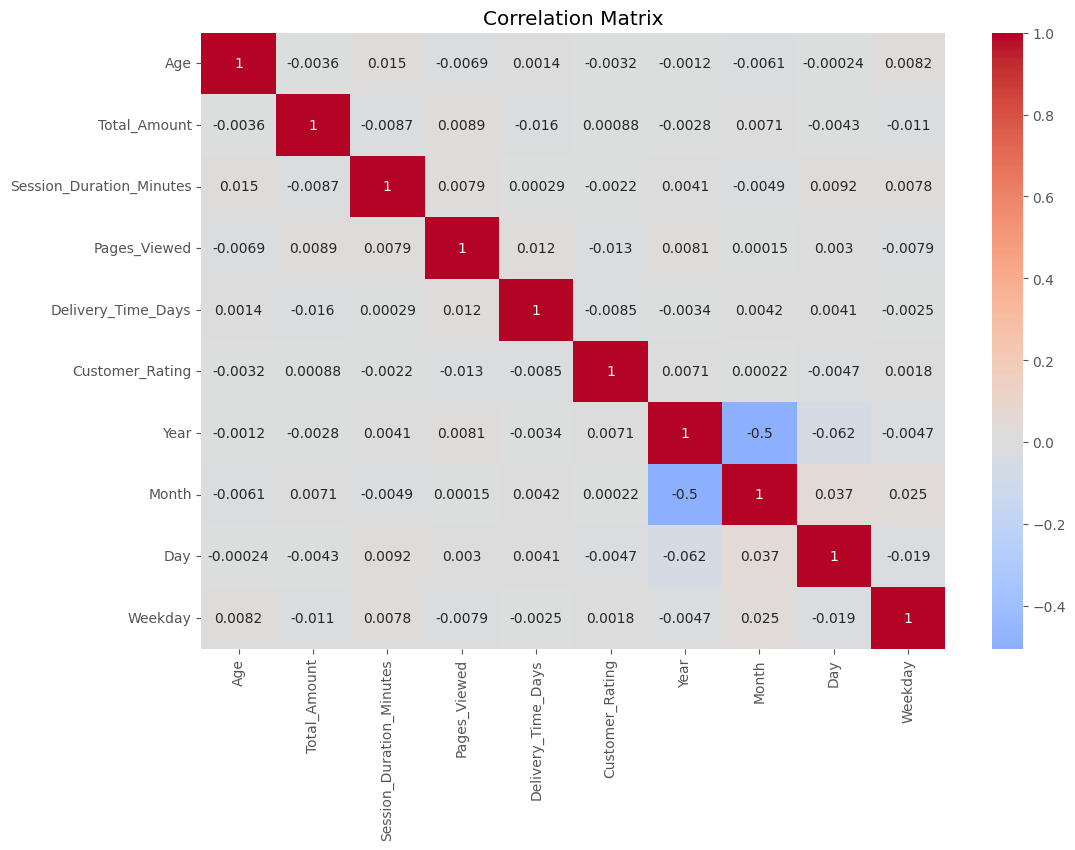

In [6]:
# heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)

plt.title("Correlation Matrix")

plt.show()

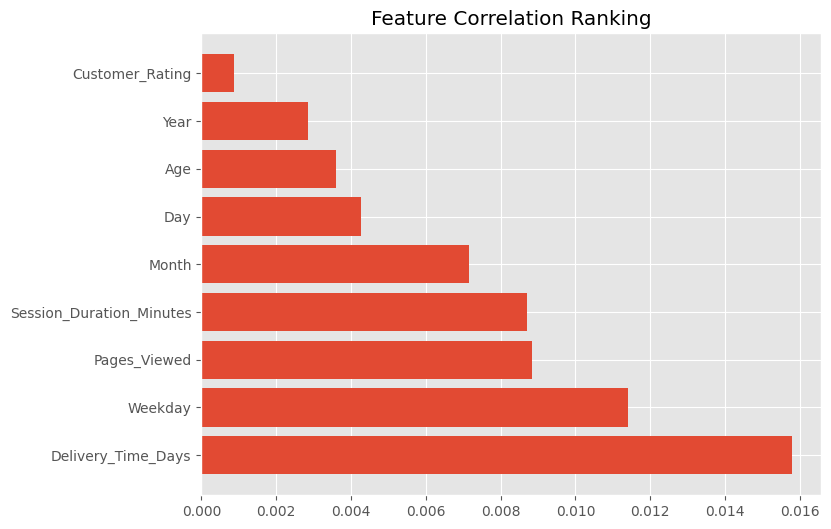

In [7]:
# correlation ranking
ranking = (
    corr[TARGET]
    .drop(TARGET)
    .abs()
    .sort_values(ascending=False)
    .to_frame("Absolute Correlation")
)

ranking

plt.figure(figsize=(8, 6))

plt.barh(ranking.index, ranking["Absolute Correlation"])

plt.title("Feature Correlation Ranking")

plt.show()

In [11]:
# multicolinearity
threshold = 0.8

high_corr = []

matrix = corr.abs()

for i in range(len(matrix.columns)):
    for j in range(i):
        value = matrix.iloc[i, j]

        if value > threshold:
            high_corr.append(
                {
                    "Feature A": matrix.columns[i],
                    "Feature B": matrix.columns[j],
                    "Correlation": round(value, 3),
                }
            )

high_corr = pd.DataFrame(high_corr)

high_corr

""


In [ ]:
# variance inflation factor
X = numeric_df.drop(columns=TARGET)

vif = pd.DataFrame()

vif["Feature"] = X.columns

vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif = vif.sort_values("VIF", ascending=False)

vif

,Feature,VIF
5,Year,74.355543
1,Session_Duration_Minutes,25.699932
2,Pages_Viewed,16.879768
4,Customer_Rating,12.937598
0,Age,11.011932
3,Delivery_Time_Days,4.476422
7,Day,4.230594
6,Month,3.480392
8,Weekday,3.283589


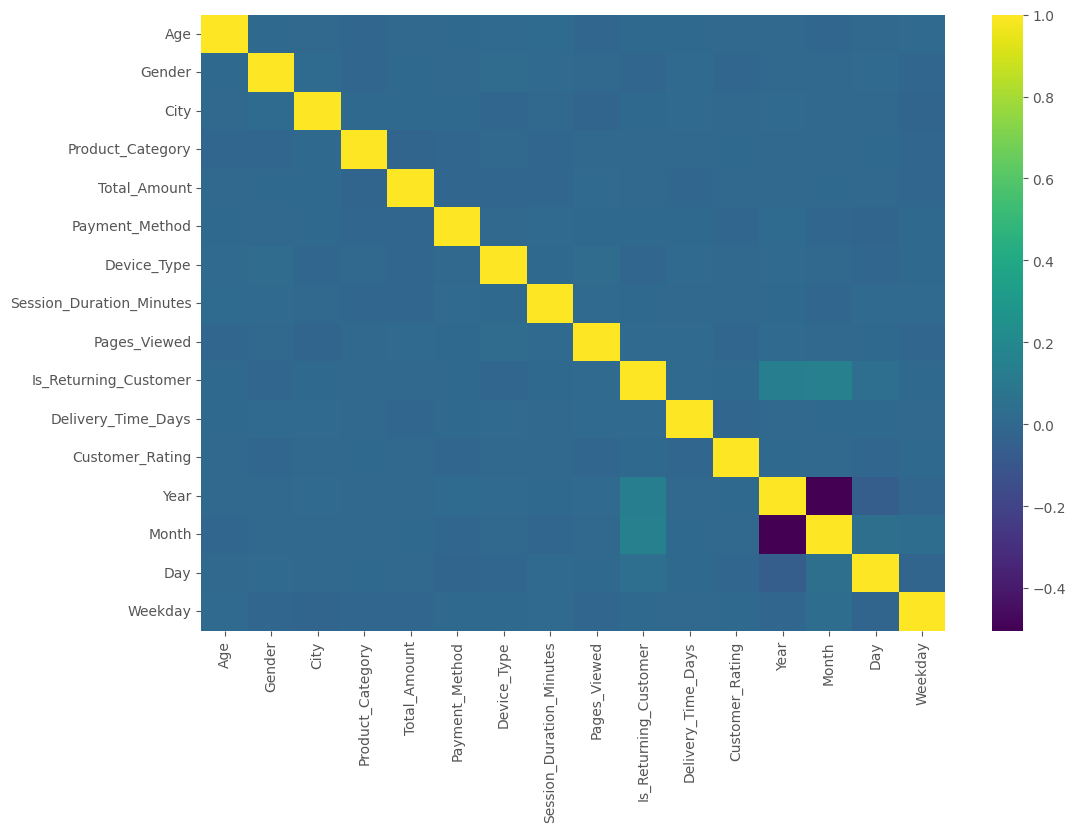

In [13]:
# categorical association
encoded = analysis_df.copy()

encoder = LabelEncoder()

for col in encoded.select_dtypes(include="object").columns:
    encoded[col] = encoder.fit_transform(encoded[col])

cat_corr = encoded.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(cat_corr, cmap="viridis")

plt.show()

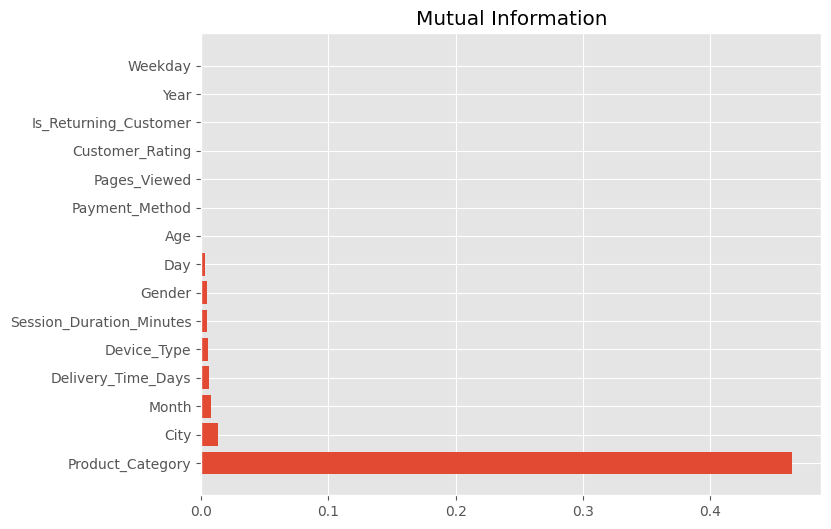

In [15]:
# mutual information
X = encoded.drop(columns=TARGET)

y = encoded[TARGET]

mi = mutual_info_regression(X, y, random_state=42)

mi = pd.Series(mi, index=X.columns).sort_values(ascending=False)

mi

plt.figure(figsize=(8, 6))

plt.barh(mi.index, mi.values)

plt.title("Mutual Information")

plt.show()

In [16]:
# feature importance
feature_summary = pd.DataFrame({"Correlation": ranking.squeeze()})

feature_summary["Mutual Information"] = mi

feature_summary = feature_summary.fillna(0)

feature_summary

,Correlation,Mutual Information
Delivery_Time_Days,0.015784,0.005880
Weekday,0.011418,0.000000
Pages_Viewed,0.008851,0.000000
Session_Duration_Minutes,0.008717,0.004661
Month,0.007150,0.007924
Day,0.004276,0.002997
Age,0.003606,0.000000
Year,0.002841,0.000000
Customer_Rating,0.000879,0.000000


In [17]:
# final feature ranking
feature_summary["Score"] = (
    feature_summary["Correlation"].rank() + feature_summary["Mutual Information"].rank()
)

feature_summary = feature_summary.sort_values("Score", ascending=False)

feature_summary

,Correlation,Mutual Information,Score
Delivery_Time_Days,0.015784,0.005880,17.0
Month,0.007150,0.007924,14.0
Session_Duration_Minutes,0.008717,0.004661,13.0
Weekday,0.011418,0.000000,11.0
Pages_Viewed,0.008851,0.000000,10.0
Day,0.004276,0.002997,10.0
Age,0.003606,0.000000,6.0
Year,0.002841,0.000000,5.0
Customer_Rating,0.000879,0.000000,4.0


# Business Insights

## Strong Features

Identify features strongly associated with revenue.

## Weak Features

Evaluate whether weak features should remain in the model.

## Multicollinearity

Highly correlated variables should be reviewed before modeling.

## Information Gain

Mutual Information identifies nonlinear relationships that are not captured by Pearson correlation.

# Recommendation

Recommended Features

- Age
- Gender
- City
- Product_Category
- Payment_Method
- Device_Type
- Session_Duration_Minutes
- Pages_Viewed
- Is_Returning_Customer
- Delivery_Time_Days
- Customer_Rating
- Year
- Month
- Weekday

Dropped Features

- Order_ID
- Customer_ID
- Unit_Price
- Quantity
- Discount_Amount